# Phase 1 - Data audit and cleaning
Goal: know exactly what is in the Task 1 data, what is broken, and what we decide to do about it. Run top to bottom. The last section saves the audited tables to `data/interim/task1/`.

In [1]:
import sys; sys.path.append("../../tools/task1")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from task1_common import *
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
t = load_task1_tables()

## 1. Load and shape
Row counts and date ranges. Test is a *later* period than train, so validation must be forward in time.

In [2]:
for k in ['deliveries_train', 'orders_test']:
    d = t[k]; print(f"{k:18s} {d.shape}  order_date {d.order_date.min()} -> {d.order_date.max()}")
for k in ['legs_train', 'legs_test']:
    d = t[k]; print(f"{k:18s} {d.shape}  date       {d.date.min()} -> {d.date.max()}")
print()
print(t['deliveries_train'].dispatch_status.value_counts().to_frame('train'))
print(t['orders_test'].dispatch_status.value_counts().to_frame('test'))

deliveries_train   (92307, 20)  order_date 2024-01-01 -> 2026-02-14
orders_test        (5014, 20)  order_date 2026-02-16 -> 2026-03-28
legs_train         (91894, 22)  date       2024-01-01 -> 2026-02-14
legs_test          (5014, 18)  date       2026-02-16 -> 2026-03-28

                 train
dispatch_status       
attempted        90351
deferred          1543
not_run            413
                 test
dispatch_status      
attempted        4924
deferred           90


## 2. Nulls and duplicates
Expected: nulls only on the `not_run` orders (never dispatched, so no route/vehicle/time).

In [4]:
for k in ['deliveries_train', 'legs_train', 'orders_test', 'legs_test']:
    d = t[k]; n = d.isna().sum()
    idcol = 'delivery_id' if 'delivery_id' in d else 'leg_id'
    print(f"{k}: nulls={n[n>0].to_dict()}  dup ids={d[idcol].duplicated().sum()}  dup rows={d.duplicated().sum()}")

d = t['deliveries_train']
print('\nstatus vs missing route_id:')
print(pd.crosstab(d.dispatch_status, d.route_id.isna()))
print('\nshare dispatched on order_date, by status:')
print((d.dispatch_date == d.order_date).groupby(d.dispatch_status).mean())

deliveries_train: nulls={'dispatch_date': 413, 'route_id': 413, 'seq_in_route': 413, 'vehicle_id': 413, 'vehicle_type': 413, 'vehicle_temp': 413, 'planned_arrival_time': 413}  dup ids=0  dup rows=0
legs_train: nulls={}  dup ids=0  dup rows=0
orders_test: nulls={}  dup ids=0  dup rows=0
legs_test: nulls={}  dup ids=0  dup rows=0

status vs missing route_id:
route_id         False  True 
dispatch_status              
attempted        90351      0
deferred          1543      0
not_run              0    413

share dispatched on order_date, by status:
dispatch_status
attempted    1.0
deferred     0.0
not_run      0.0
dtype: float64


## 3. Order <-> leg join integrity
Each dispatched order must match exactly one leg on `(route_id, seq_in_route)`, and the shared fields must agree.

In [5]:
tr = join_orders_to_legs(t['deliveries_train'], t['legs_train'])
te = join_orders_to_legs(t['orders_test'], t['legs_test'])
print('train joined', len(tr), '| dispatched orders', t['deliveries_train'].route_id.notna().sum(), '| legs', len(t['legs_train']))
print('test  joined', len(te), '| dispatched orders', t['orders_test'].route_id.notna().sum(), '| legs', len(t['legs_test']))
print('legs with no order (train/test):', len(set(t['legs_train'].leg_id) - set(tr.leg_id)), len(set(t['legs_test'].leg_id) - set(te.leg_id)))

def agreement(df):
    return pd.Series({
        'planned_arrival': (df.planned_arrival_time == df.planned_arrival_time_leg).mean(),
        'outlet == to_outlet': (df.outlet_id == df.to_outlet).mean(),
        'brand': (df.brand == df.brand_leg).mean(),
        'district': (df.district == df.district_leg).mean(),
        'depot': (df.depot == df.depot_leg).mean(),
        'vehicle_id': (df.vehicle_id == df.vehicle_id_leg).mean(),
        'dispatch_date == leg date': (df.dispatch_date == df.date).mean(),
    })
print(pd.DataFrame({'train': agreement(tr), 'test': agreement(te)}))

o = t['outlets'].set_index('outlet_id')
for name, df in [('train', tr), ('test', te)]:
    ok_open = (df.window_open_time.values == o.loc[df.outlet_id, 'window_open_time'].values).mean()
    ok_close = (df.window_close_time.values == o.loc[df.outlet_id, 'window_close_time'].values).mean()
    print(f'{name}: order window == outlets.csv window -> open {ok_open:.4f}, close {ok_close:.4f}')

train joined 91894 | dispatched orders 91894 | legs 91894
test  joined 5014 | dispatched orders 5014 | legs 5014
legs with no order (train/test): 0 0
                           train  test
planned_arrival              1.0   1.0
outlet == to_outlet          1.0   1.0
brand                        1.0   1.0
district                     1.0   1.0
depot                        1.0   1.0
vehicle_id                   1.0   1.0
dispatch_date == leg date    1.0   1.0
train: order window == outlets.csv window -> open 1.0000, close 1.0000
test: order window == outlets.csv window -> open 1.0000, close 1.0000


## 4. Time-column sanity
Convert clock times to minutes. Things to establish: any midnight wrap? how do planned and actual times relate? (`arrival = depart + travel` up to rounding; planned travel is a *clear-road* assumption.)

midnight wrap  arrival<depart: 0 | leave<arrival: 0
max clock minute  train/test: 1315 1413 / 750 (1440 = midnight)

planned: depart+travel == arrival   : 1.0
actual : arrival - (depart+travel)  : {np.int64(0): 68820, np.int64(1): 11556, np.int64(-1): 11518} <- +-1 min rounding only
actual : depart == previous leave   : 1.0

arrival delay vs plan (min):
         count  mean   std    min   25%   50%   75%    max
brand                                                     
Fresh  87457.0  51.8  60.7 -113.0  16.0  34.0  66.0  930.0
Style   2733.0  67.1  75.6  -39.0  28.0  44.0  74.0  677.0
Tech    1704.0  69.6  76.6  -42.0  31.0  46.0  78.0  687.0

delay by position in route:
seq         0      1      2      3     4     5     6     7     8
count   25198  21371  16222  12120  7464  5296  2527  1110   452
mean     41.6   49.8   50.6   60.0  66.6  69.3  71.1  64.5  92.6
median   24.0   31.0   38.0   45.0  51.0  56.0  59.0  55.0  87.0

actual/planned travel ratio: {'count': 91894.0, 'mean': 1.7

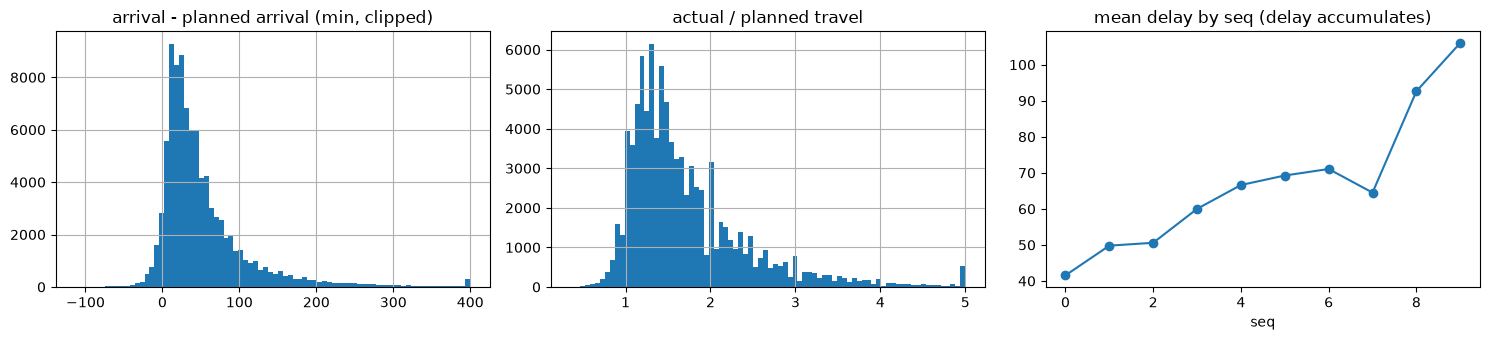

In [7]:
TIME_COLS = ['planned_depart_time', 'planned_arrival_time', 'actual_depart_time', 'arrival_time',
             'leave_outlet_time', 'window_open_time', 'window_close_time']
def add_minutes(df):
    df = df.copy()
    for c in TIME_COLS:
        if c in df: df[c + '_m'] = hhmm_to_min(df[c])
    return df.sort_values(['route_id', 'seq']).reset_index(drop=True)
tr, te = add_minutes(tr), add_minutes(te)

print('midnight wrap  arrival<depart:', (tr.arrival_time_m < tr.actual_depart_time_m).sum(),
      '| leave<arrival:', (tr.leave_outlet_time_m < tr.arrival_time_m).sum())
print('max clock minute  train/test:', tr.arrival_time_m.max(), tr.leave_outlet_time_m.max(), '/', te.planned_arrival_time_m.max(), '(1440 = midnight)')

print('\nplanned: depart+travel == arrival   :', ((tr.planned_depart_time_m + tr.planned_travel_duration_min) == tr.planned_arrival_time_m).mean())
gap = tr.arrival_time_m - tr.actual_depart_time_m - tr.actual_travel_duration_min
print('actual : arrival - (depart+travel)  :', gap.value_counts().to_dict(), '<- +-1 min rounding only')
prev_leave = tr.groupby('route_id').leave_outlet_time_m.shift()
print('actual : depart == previous leave   :', (tr.actual_depart_time_m == prev_leave)[prev_leave.notna()].mean())

tr['delay_min'] = tr.arrival_time_m - tr.planned_arrival_time_m
tr['depart_delay_min'] = tr.actual_depart_time_m - tr.planned_depart_time_m
tr['travel_ratio'] = tr.actual_travel_duration_min / tr.planned_travel_duration_min
print('\narrival delay vs plan (min):'); print(tr.groupby('brand').delay_min.describe().round(1))
print('\ndelay by position in route:'); print(tr.groupby('seq').delay_min.agg(['count', 'mean', 'median']).round(1).head(9).T)
print('\nactual/planned travel ratio:', tr.travel_ratio.describe().round(2).to_dict())

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
tr.delay_min.clip(-120, 400).hist(bins=80, ax=ax[0]); ax[0].set_title('arrival - planned arrival (min, clipped)')
tr.travel_ratio.clip(0, 5).hist(bins=80, ax=ax[1]); ax[1].set_title('actual / planned travel')
tr.groupby('seq').delay_min.mean().head(12).plot(marker='o', ax=ax[2]); ax[2].set_title('mean delay by seq (delay accumulates)')
plt.tight_layout(); plt.show()

## 5. Outliers
Two tails to understand: the time spent at the outlet (`leave - arrival`, the raw stay) and arrival delay. Question for each: data error, or real behaviour we must model?

stay at outlet (leave - arrival), min:
         count  mean   std  min   50%    99%  99.9%    max
brand                                                     
Fresh  87457.0  18.0  11.3  2.0  15.0   62.0  100.0  201.0
Style   2733.0  53.4  31.7  8.0  47.0  167.7  268.0  301.0
Tech    1704.0  60.7  39.0  7.0  52.0  195.0  340.7  428.0

stays <= 0: 0 | stays > 240: 13

median stay vs dispatcher allowance (the allowance is a plan, not an observation):
                 stay_min  service_allowance_min
brand dock_type                                 
Fresh rear_dock      15.0                   15.0
      street         15.0                   16.0
Style mall_bay       64.0                   59.0
      rear_dock      30.0                   38.0
      street         45.0                   46.0
Tech  mall_bay       75.0                   55.0
      rear_dock      35.0                   43.0
      street         67.0                   55.0
stay / allowance ratio: {'count': 91894.0, 'mean': 1.18, 's

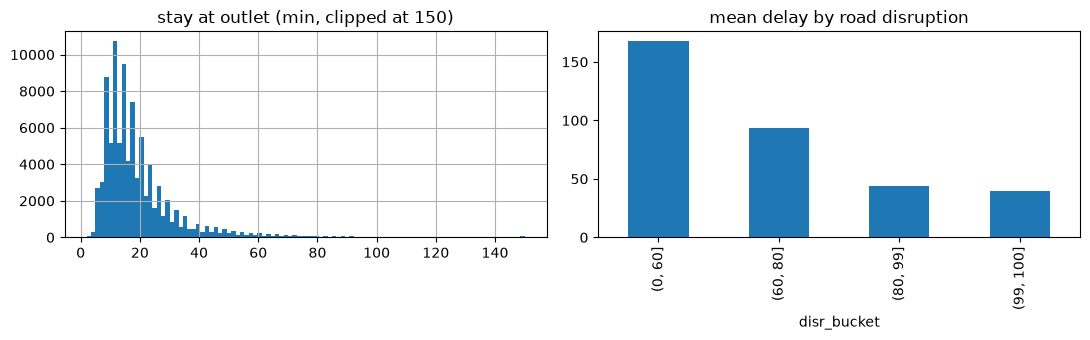

In [8]:
tr['stay_min'] = tr.leave_outlet_time_m - tr.arrival_time_m
print('stay at outlet (leave - arrival), min:'); print(tr.groupby('brand').stay_min.describe(percentiles=[.5, .99, .999]).round(1))
print('\nstays <= 0:', (tr.stay_min <= 0).sum(), '| stays > 240:', (tr.stay_min > 240).sum())

tr = tr.merge(t['outlets'][['outlet_id', 'dock_type', 'parking_constraint']], on='outlet_id', how='left') \
       .merge(t['service_allowance'], on=['brand', 'dock_type'], how='left')
print('\nmedian stay vs dispatcher allowance (the allowance is a plan, not an observation):')
print(tr.groupby(['brand', 'dock_type'])[['stay_min', 'service_allowance_min']].median())
print('stay / allowance ratio:', (tr.stay_min / tr.service_allowance_min).describe().round(2).to_dict())

big = tr[tr.delay_min > 300]
print(f'\ndelay > 300 min: {len(big)} legs on {big.date.nunique()} dates; by brand {big.brand.value_counts().to_dict()}')
tr = tr.merge(t['roads'], on=['district', 'date'], how='left')
tr['disr_bucket'] = pd.cut(tr.disruption_index, [0, 60, 80, 99, 100])
print('\nmean delay / travel ratio by road disruption bucket:')
print(tr.groupby('disr_bucket', observed=True)[['delay_min', 'travel_ratio']].agg(['count', 'mean']).round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
tr.stay_min.clip(0, 150).hist(bins=100, ax=ax[0]); ax[0].set_title('stay at outlet (min, clipped at 150)')
tr.groupby('disr_bucket', observed=True).delay_min.mean().plot.bar(ax=ax[1]); ax[1].set_title('mean delay by road disruption')
plt.tight_layout(); plt.show()

## 6. Train vs test shift
Test covers 2026-02-16 to 2026-03-28. Compare mix and numeric distributions, and look at the same season a year earlier.

In [9]:
te['date'] = pd.to_datetime(te.date); tr['date'] = pd.to_datetime(tr.date)
print('train legs per month:'); print(tr.groupby(tr.date.dt.to_period('M')).size().to_string())

def share(col): return pd.concat([tr[col].value_counts(normalize=True).rename('train'), te[col].value_counts(normalize=True).rename('test')], axis=1).round(3)
for c in ['brand', 'depot', 'vehicle_type', 'vehicle_temp', 'temp_requirement', 'dow', 'monsoon', 'dispatch_status']:
    print(f'\n-- {c}'); print(share(c))

num = ['order_units', 'order_weight_kg', 'order_volume_m3', 'distance_km', 'planned_travel_duration_min', 'planned_arrival_time_m', 'seq']
same_season = tr[(tr.date >= '2025-02-16') & (tr.date <= '2025-03-28')]
print('\nnumeric means: train all | train same season 2025 | test')
print(pd.DataFrame({'train': tr[num].mean(), 'train_2025_same_season': same_season[num].mean(), 'test': te[num].mean()}).round(2))

cal = t['calendar'].assign(date=lambda d: pd.to_datetime(d.date))
for name, df in [('train', tr), ('test', te)]:
    c = df[['date']].merge(cal, on='date', how='left')
    print(f"\n{name}: payday {c.is_payday.mean():.3f} | festival_ramp>0 {(c.festival_ramp>0).mean():.3f} | holiday {c.is_holiday.mean():.3f} | non-operating-day legs {(c.is_operating==0).sum()}")
print('festivals in test window:', cal[(cal.date >= '2026-02-16') & (cal.date <= '2026-03-28') & (cal.festival.notna())][['date', 'festival']].values.tolist())

train legs per month:
date
2024-01    3776
2024-02    3501
2024-03    3642
2024-04    3481
2024-05    3623
2024-06    3457
2024-07    3783
2024-08    3788
2024-09    3480
2024-10    3802
2024-11    3618
2024-12    3495
2025-01    3783
2025-02    3362
2025-03    3586
2025-04    3341
2025-05    3582
2025-06    3461
2025-07    3789
2025-08    3634
2025-09    3604
2025-10    3743
2025-11    3466
2025-12    3636
2026-01    3769
2026-02    1692
Freq: M

-- brand
       train   test
brand              
Fresh  0.952  0.953
Style  0.030  0.030
Tech   0.019  0.018

-- depot
            train   test
depot                   
Peliyagoda  0.612  0.612
Kandy       0.388  0.388

-- vehicle_type
              train   test
vehicle_type              
truck         0.864  0.863
van           0.136  0.137

-- vehicle_temp
              train   test
vehicle_temp              
ambient       0.622  0.621
reefer        0.378  0.379

-- temp_requirement
                  train   test
temp_requirement           

## 7. Reference-table coverage
Every train/test row must find its calendar, traffic (district x hour x monsoon) and road-condition (district x date) record, otherwise the feature has to be imputed.

In [10]:
roads = t['roads'].assign(date=lambda x: pd.to_datetime(x.date))
def coverage(df, name):
    d = df.copy(); d['hour'] = (d.planned_arrival_time_m // 60).astype(int)
    traffic_hit = d.merge(t['traffic'], on=['district', 'hour', 'monsoon'], how='left').speed_index.notna().mean()
    roads_hit = d[['district', 'date']].merge(roads, on=['district', 'date'], how='left').disruption_index.notna().mean()
    cal_hit = d[['date']].merge(cal[['date']].assign(_hit=1), on='date', how='left')._hit.notna().mean()
    print(f'{name}: traffic {traffic_hit:.4f} | roads {roads_hit:.4f} | calendar {cal_hit:.4f}')
coverage(tr, 'train'); coverage(te, 'test')
tf = t['traffic']
print('\ntraffic_speed grid:', tf.district.nunique(), 'districts x', tf.hour.nunique(), 'hours x', tf.monsoon.nunique(), 'monsoon =', len(tf), 'rows')
print('road_conditions range:', t['roads'].date.min(), '->', t['roads'].date.max(), '| covers test:', t['roads'].date.max() >= '2026-03-28')
print('speed_index range:', tf.speed_index.min(), '-', tf.speed_index.max(), '| disruption_index range:', t['roads'].disruption_index.min(), '-', t['roads'].disruption_index.max())
print('district names agree across files:', set(tr.district) == set(tf.district) == set(t['roads'].district))

train: traffic 1.0000 | roads 1.0000 | calendar 1.0000
test: traffic 1.0000 | roads 1.0000 | calendar 1.0000

traffic_speed grid: 12 districts x 24 hours x 2 monsoon = 576 rows
road_conditions range: 2024-01-01 -> 2026-06-28 | covers test: True
speed_index range: 32 - 100 | disruption_index range: 40 - 100
district names agree across files: True


## 8. Save audited tables and record decisions
Train keeps only dispatched orders (the 413 `not_run` have no leg and therefore no label). Columns added here (`*_m` from actual times, `delay_min`, `depart_delay_min`, `travel_ratio`, `stay_min`) use actual times and are **audit-only** - anything derived from `actual_*`, `arrival_time` or `leave_outlet_time` must never become a test-time feature.

In [11]:
INTERIM.mkdir(parents=True, exist_ok=True)
train_out = tr.drop(columns=['disr_bucket'])
train_out.to_pickle(INTERIM / 'train_joined.pkl'); te.to_pickle(INTERIM / 'test_joined.pkl')
print('saved train', train_out.shape, '| test', te.shape, '->', INTERIM)

saved train (91894, 56) | test (5014, 41) -> C:\Users\Asanka\Desktop\Hackbots_Datathon\data\interim


### Findings and cleaning decisions
*Edit after running; this feeds the preprocessing document.*

| # | Finding | Decision |
|---|---|---|
| 1 | `not_run` orders (413) have no route, vehicle or times. | Excluded from Task 1 training; kept for Task 2A demand counts. |
| 2 | Orders join one-to-one to legs; shared fields agree. | No repair needed. |
| 3 | No midnight wrap in any clock column. | No day-offset unwrapping needed. |
| 4 | `arrival = depart + travel` within +-1 min (rounding). | Treat minute columns as exact up to +-1. |
| 5 | Actual travel is ~1.7x the planned clear-road travel, and delay accumulates along the route. | Planned times are optimistic; traffic, road disruption and route position are key lateness features. |
| 6 | ~4% of vehicles arrive before the window opens. | Service-time label must start at `max(arrival, window_open)`. |
| 7 | Long delays track road disruption (mean delay ~168 min when disruption <= 60 vs ~39 min when clear); long stays occur in Style/Tech; no stay <= 0. | Keep as real behaviour; use disruption/traffic features and a log/robust target. |
| 8 | Test is a later period (Feb-Mar 2026). | Forward-in-time validation. |
| 9 | Test is 66% monsoon legs vs 47% in train, and has no festival/holiday days (train: 19% in festival ramp). | Validate on monsoon-heavy recent months; do not over-weight festival features. |
